# Numerical solution to differential equation

Problem statement:
Given a second order differential equation of dependent variable x and independent variable time t, and given the initial values (at time $t=0$) for the position $x(0)$ and velocity $\dot{x}(0)$, the aim is to solve after time duration $t$, the position $x(t)$ and velocity $\dot{x}(t)$.

$$
\ddot{x} = f(x, t)
$$

The idea is to decompose the second order differential equation into two first order differential equations

Let us denote the first order derivative as velocity $v$ and is given by

$$
v := \dot{x} \qquad \Rightarrow \qquad \dot{x} = v
$$

so that the second differential equation can be written in terms of $x, t, v$ as

$$
\ddot{x} = \dot{[\dot{x}]} = \dot{v} = f(x, t)
$$

The set of first order differential equations that are equivalent to the given second order differential equation is

\begin{align}
\dot{x} &= v \\
\dot{v} &= f(x, t)
\end{align}

# Generalized position and velocity

If we represent the set of position and velocity as the **generalized position** of the particle, it can be represented as a ket that is a 2-column vector
$$
|\psi\rangle =
\left(
\begin{matrix}
x \\
v
\end{matrix}
\right)
$$

Here, ket resides in the two-dimensional space spanned by position and momentum. This space is called **phase space** of the particle.

Similarly, if we represent the set of rate of change of position and rate of change of velocity as the **generalized velocity** of the particle, it can be represented as a ket that is a 2-column vector

$$
\frac{\mathrm{d} |\psi\rangle}{\mathrm{d} t} =
\left(
\begin{matrix}
\dot{x} \\
\dot{v}
\end{matrix}
\right)
=
\left(
\begin{matrix}
v \\
f(x, t)
\end{matrix}
\right)
$$


# Finite difference formula for velocity

If we discretize the time axis with equally spaced time samples ${t_n}$ with spacing $\Delta t = t_n - t_{n-1}$, then

$$
\frac{\mathrm{d} |\psi\rangle}{\mathrm{d} t} \sim \frac{|\psi(t_n)\rangle -|\psi(t_{n-1})\rangle}{\Delta t}
$$


If the samples of kets are denoted by $|\psi(t_n)\rangle = |\psi_n\rangle$, then

$$
|\psi_n\rangle =
\left(
\begin{matrix}
x_n \\
v_n
\end{matrix}
\right)
$$


# Recurrence relation

Due to the finite difference formula, the values of ket at timestamp $n$ can be expressed in terms of values of ket at $n-1$ and other independent variables.

\begin{align}
|\psi_n\rangle &\sim |\psi_{n-1}\rangle  + \Delta t |\psi_{n}\rangle^{'},\\
\left(
\begin{matrix}
x_{n} \\
v_{n}
\end{matrix}
\right)
&=
\left(
\begin{matrix}
x_{n-1} \\
v_{n-1}
\end{matrix}
\right)
+
\Delta t
\left(
\begin{matrix}
\dot{x}_{n} \\
\dot{v}_{n}
\end{matrix}
\right) \\
&= \left(
\begin{matrix}
x_{n-1} + v_n \Delta t \\
v_{n-1} + f(x_n, t_n)\Delta t
\end{matrix}
\right)
\end{align}

But let us express $v_n$ on the RHS in terms of $v_{n-1}$ so that

$$
\left(
\begin{matrix}
x_{n} \\
v_{n}
\end{matrix}
\right)
=
\left(
\begin{matrix}
x_{n-1} + v_{n-1} \Delta t + f(x_n, t_n)(\Delta t)^2 \\
v_{n-1} + f(x_n, t_n)\Delta t
\end{matrix}
\right)
$$

If the error propagation due to $(\Delta t)^2$ is neglected, then

$$
\left(
\begin{matrix}
x_{n} \\
v_{n}
\end{matrix}
\right)
=
\left(
\begin{matrix}
x_{n-1} + v_{n-1} \Delta t \\
v_{n-1} + f(x_n, t_n)\Delta t
\end{matrix}
\right)
$$

The RHS can be considered as a matrix transformation so that

$$
\left(
\begin{matrix}
x_{n} \\
v_{n}
\end{matrix}
\right)
=
\left[
\begin{matrix}
1  & \Delta t \\
f(x_n, t_n)\Delta t    & 1
\end{matrix}
\right]
\left(
\begin{matrix}
x_{n-1}\\
v_{n-1}
\end{matrix}
\right)
$$

# Simple Harmonic Motion

$$
\ddot{x} = - \omega^2 x
$$

so that $f(x, t) = -\omega^2 x$. The evolver is

$$
U =
\left[
\begin{matrix}
1  & \Delta t \\
- \omega^2 \Delta t    & 1
\end{matrix}
\right]
$$

In [ ]:
# Implementation of recurrence relation
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
dt = 1e-4
omega = 2
n = 10 # number of periods
ts = np.arange(0, 2.0*np.pi/omega*n, dt)

In [ ]:
# initial ket (x0, v0) = (0, 1)
ket0 = np.array([0, 2])

In [ ]:
ket0

array([0, 2])

In [ ]:
def evolver(ket, step):
    x, v = ket
    stepper = np.array([[1, step], [-1.0*omega**2*step, 1]])
    evolved_ket = stepper.dot(ket)
    return evolved_ket

In [ ]:
kets = np.zeros((len(ts),2))

In [ ]:
for i in range(len(ts)):
    if i==0:
        evolved_ket = ket0
        kets[i] = evolved_ket
    else:
        evolved_ket = evolver(kets[i-1], dt)
        kets[i] = evolved_ket

In [ ]:
xs, vs = kets[:,0], kets[:,1]

Text(0.5, 1.0, 'simple harmonic motion')

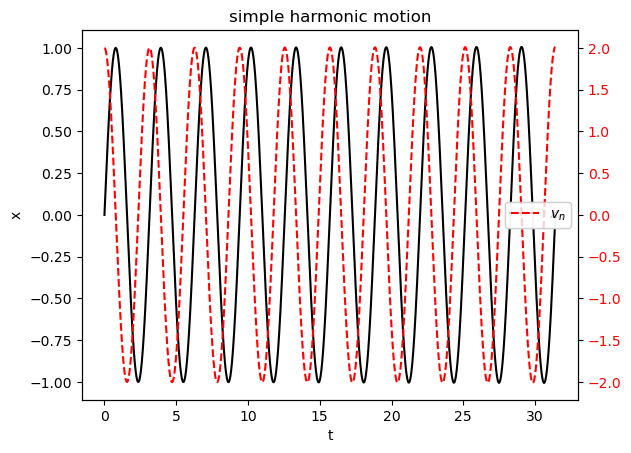

In [ ]:
fig, ax = plt.subplots()
ax.plot(ts, xs, 'k-', label=r'$x_n$')
ax2 = ax.twinx()
ax2.plot(ts, vs, 'r--', label=r'$v_n$')
ax.set_xlabel('t')
ax.set_ylabel('x')
ax.legend()

ax2.tick_params(labelcolor='r')
ax2.set_xlabel('v')
ax2.legend()
ax.set_title('simple harmonic motion')

# Configuration space

The space spanned by the position coordinates of the system is called the configuration space. Here, the particle is in one-dimensional motion. Hence, the configuration space is one dimensional. However, not all of the axis is spanned. There are turning points due to the harmonic motion.

Since we started with initial velocity at origin, the particle reached maximum position $x_{max}$ where the velocity is zero. Similarly, the other turning point is at $x_{min}$.

The trajectory of the particle can be represented as set of the $x(t), v(t)$ parametrized curves, where $t$ is the parameter.

# Phase space

The space spanned by the position and velocity coordinates is called the phase space. The phase space of the particle in 1D simple harmonic motion will be two-dimensional.

The trajectory of the particle is represented as a single parametrized curve.

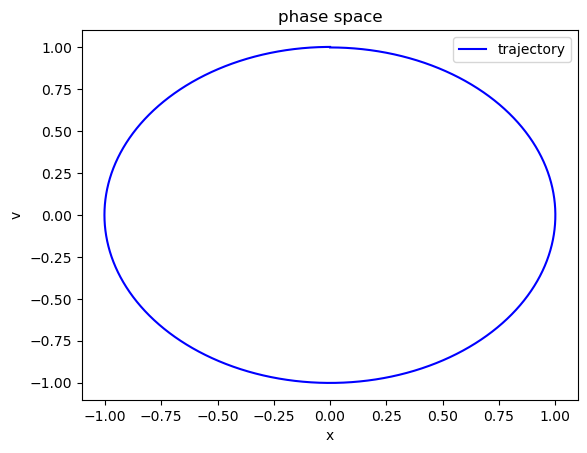

In [ ]:
# Phase space visualization

fig, ax = plt.subplots()
ax.plot(xs, vs, 'b-', label='trajectory')
ax.set_xlabel('x')
ax.set_ylabel('v')
ax.set_title('phase space')
ax.legend()

# Acceleration due to gravity

Let us consider a two dimensional problem of a particle projected at an angle to the horizontal. The aim is to solve for the trajectory of the particle.

We have

$$
\vec{a} = -g \hat{j},
$$
where $g$ is the acceleration due to gravity.

This is a vector equation that can be decomposed into two scalar equations.

\begin{align}
\ddot{x} &= 0 \\
\ddot{y}  &= -g
\end{align}

If we denote the velocity components as

$$
\vec{v} = v_x \hat{i} + v_y \hat{j}
$$

Then the set of two second order differential equations can be decomposed as a set of four first order differential equations

\begin{align}
\dot{x} &= v_x \\
\dot{y} &= v_y \\
\dot{v_x} &= 0 \\
\dot{v_y} &= -g
\end{align}

Thus if the state of the system is represented by the 4-column ket

$$
|\psi\rangle =
\left(
\begin{matrix}
x \\
y \\
v_x \\
v_y
\end{matrix}
\right),
$$

then the velocity of the state is given by

$$
\frac{\mathrm{d} |\psi\rangle}{\mathrm{d} t}  =
\left(
\begin{matrix}
\dot{x} \\
\dot{y} \\
\dot{v_x} \\
\dot{v_y}
\end{matrix}
\right)
=
\left(
\begin{matrix}
v_x \\
v_y \\
0 \\
-g
\end{matrix}
\right)
$$


We can extend the finite difference method to four dimensional ket and solve for the trajectory.

The evolution is given by

$$
|\psi_n\rangle = U |\psi_{n-1}\rangle + |\psi_0\rangle,
$$

where the evolver is then given by

$$
U =
\left[
\begin{matrix}
1  &  0  & \Delta t & 0\\
0    &  1 & 0 & \Delta t \\
0 &  0  & 1 & 0 \\
0 &  0 &  0 & 1
\end{matrix}
\right]
$$

and

$$
|\psi_0 \rangle =
\left(
\begin{matrix}
0  \\
0  \\
0  \\
-g \Delta t
\end{matrix}
\right)
$$

In [ ]:
dt = 1e-3
g = 9.8 # acceleration due to gravity
alpha =  np.pi/3.0 # np.pi/2.0 projectile angle
v0 = 1 # initial speed
T = 2.0*v0*np.sin(alpha)/g # time of flight
ts = np.arange(0, T, dt)

In [ ]:
T

np.float64(0.1767398783233548)

In [ ]:
# initial ket (x0, y0, vx0, vy0)
x0 = 0
y0 = 0
vx0 = v0*np.cos(alpha)
vy0 = v0*np.sin(alpha)
ket0 = np.array([x0, y0, vx0, vy0])

In [ ]:
def evolver_projectile(ket, step):
    x, y, vx, vy = ket
    stepper = np.array([[1, 0, step, 0], [0, 1, 0, step], [0, 0, 1, 0], [0, 0, 0, 1]])
    offset = np.array([0, 0, 0, -1.0*g*step])
    evolved_ket = stepper.dot(ket) + offset
    return evolved_ket

In [ ]:
kets = np.zeros((len(ts),4))

In [ ]:
for i in range(len(ts)):
    if i==0:
        evolved_ket = ket0
        kets[i] = evolved_ket
    else:
        evolved_ket = evolver_projectile(kets[i-1], dt)
        kets[i] = evolved_ket

In [ ]:
xs, ys, vxs, vys = kets[:,0], kets[:,1], kets[:,2], kets[:,3]

Text(0.5, 1.0, 'projectile motion under gravity')

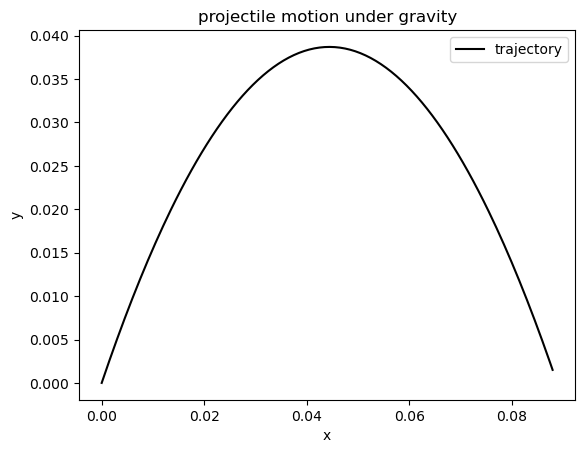

In [ ]:
fig, ax = plt.subplots()
ax.plot(xs, ys, 'k-', label='trajectory')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.set_title('projectile motion under gravity')

# Step potential

Let us now solve TISE the particle encountering a step potential